In [1]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import torch
import os
import random
import matplotlib.pyplot as plt
import torch
import random
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
import csv


In [2]:
transform = transforms.Compose([
        transforms.ToTensor()
        ])


In [3]:
from models import PolygonDataset
from cls_utils import LATENT_DIM, LinearClassifier, evaluate_model

In [4]:
file_path = "accuracy_xshift.csv"
header = ["mode", "degree", "accuracy"]

In [ ]:
if not os.path.exists(file_path):
    with open(file_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(header)

In [5]:
device = "cuda" 

In [6]:
model_no_op = LinearClassifier(num_classes=9).to(device)
mode="no_op"
save_dir = f"checkpoints/mnist_xshift_new_arch_cls_{mode}"

In [7]:
best_ckpt = torch.load(os.path.join  (save_dir, "best.pth"))
model_no_op.load_state_dict(best_ckpt['model_state_dict'])

<All keys matched successfully>

In [8]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = []

for d in (degrees):
    ds = PolygonDataset(
        csv_file="mnist_dataset_split.csv",
        split="test",
        transform=transform,
        transform_type="shift_x",
        keep_degrees=[d],
    )
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    _, acc = evaluate_model(model_no_op, loader, device, mode="no_op")
    with open(file_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["no_op", d, acc])



[NO_OP] Eval: Loss=0.3325, Acc=0.8946
[NO_OP] Eval: Loss=0.3373, Acc=0.8934
[NO_OP] Eval: Loss=0.3709, Acc=0.8817
[NO_OP] Eval: Loss=0.6392, Acc=0.8008
[NO_OP] Eval: Loss=1.4488, Acc=0.5943
[NO_OP] Eval: Loss=2.6590, Acc=0.3881
[NO_OP] Eval: Loss=3.5566, Acc=0.2962
[NO_OP] Eval: Loss=3.7233, Acc=0.2826
[NO_OP] Eval: Loss=3.2099, Acc=0.3356
[NO_OP] Eval: Loss=2.3764, Acc=0.4414
[NO_OP] Eval: Loss=1.4029, Acc=0.6163
[NO_OP] Eval: Loss=0.6595, Acc=0.7850
[NO_OP] Eval: Loss=0.3822, Acc=0.8754
[NO_OP] Eval: Loss=0.3334, Acc=0.8932


In [43]:
model_fixed_op = LinearClassifier(block_size=14, num_classes=9).to(device)
mode="fixed_op"
save_dir = f"checkpoints/mnist_xshift_new_arch_cls_{mode}"

In [44]:
best_ckpt = torch.load(os.path.join  (save_dir, "best.pth"))
model_fixed_op.load_state_dict(best_ckpt['model_state_dict'])

<All keys matched successfully>

In [11]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = []

for d in (degrees):
    ds = PolygonDataset(
        csv_file="mnist_dataset_split.csv",
        split="test",
        transform=transform,
        transform_type="shift_x",
        keep_degrees=[d],
    )
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    _,acc=evaluate_model(model_fixed_op, loader, device, mode="fixed_op")
    with open(file_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["fixed_op", d, acc])

[FIXED_OP] Eval: Loss=0.1360, Acc=0.9572
[FIXED_OP] Eval: Loss=0.1287, Acc=0.9602
[FIXED_OP] Eval: Loss=0.1260, Acc=0.9597
[FIXED_OP] Eval: Loss=0.1315, Acc=0.9597
[FIXED_OP] Eval: Loss=0.1427, Acc=0.9560
[FIXED_OP] Eval: Loss=0.1654, Acc=0.9486
[FIXED_OP] Eval: Loss=0.2032, Acc=0.9383
[FIXED_OP] Eval: Loss=0.2508, Acc=0.9227
[FIXED_OP] Eval: Loss=0.2124, Acc=0.9358
[FIXED_OP] Eval: Loss=0.1736, Acc=0.9459
[FIXED_OP] Eval: Loss=0.1467, Acc=0.9526
[FIXED_OP] Eval: Loss=0.1338, Acc=0.9586
[FIXED_OP] Eval: Loss=0.1289, Acc=0.9591
[FIXED_OP] Eval: Loss=0.1339, Acc=0.9592


In [45]:
trained_degrees = [24, 26, 0, 2, 4]
val_set   = PolygonDataset("mnist_dataset_split.csv", split="val",   
                            transform=transform,
                            transform_type="shift_x",
                            keep_degrees=trained_degrees)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)

In [46]:
import random
import torch
from tqdm import tqdm

# 1. Collect all items into one flat list
all_items = []
for img_anchor, deg_anchor, _, _, _ in tqdm(val_loader):
    for i in range(img_anchor.size(0)):
        all_items.append((img_anchor[i], deg_anchor[i]))

# 2. Sample 200 items once from the entire pool
random.seed(42)
samples = random.sample(all_items, 2000)

# 3. Batch process
imgs = torch.stack([s[0] for s in samples]).to(device)
degs = torch.tensor([s[1] for s in samples]).to(device)

with torch.no_grad():
    # Canonical rotation indexes and forward pass
    emb, _ = model_fixed_op(imgs, skip_transform=False, degs=-(degs // 2))

# Store as a single embedding tensor
ref_embeddings = emb.cpu()


100%|██████████| 212/212 [00:19<00:00, 10.64it/s]


(array([417., 387., 378.,   0.,   0.,   0., 412., 406.]),
 array([ 0.,  2.,  4., 10., 20., 22., 24., 26., 28.]),
 <BarContainer object of 8 artists>)

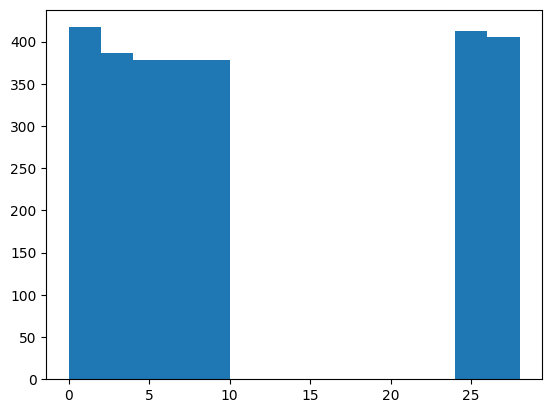

In [14]:
plt.hist(degs.cpu(),bins=[0,2,4,10,20,22,24,26,28])

In [40]:
def evaluate_with_refs(model, loader, ref_images, device, k):
    model.eval()
    
    # ref_images: (K, D) - Used only for finding the best rotation
    ref_images = ref_images.to(device)
    K = ref_images.size(0) 
    
    ops = torch.arange(14, device=device)
    total = 0
    correct = 0
    correct_deg = 0

    with torch.no_grad():
        for img_anchor, d, cls, _, _ in (loader):
            img_anchor = img_anchor.to(device)
            d = d.to(device)
            cls = cls.to(device)
            B = img_anchor.size(0)

            # 1. Rotate & Forward pass for all 14 rotations
            #img14 = img_anchor.unsqueeze(1).repeat(1, 14, 1, 1, 1).view(B * 14, *img_anchor.shape[1:])
            
            emb14, pred14 = model(img_anchor, skip_transform=False, degs=None) # shape: (B*14, D)
            #print(emb14.shape)

            # 2. Stage 1: Find best rotation (Agnostic k-NN)
            # Distance from every rotation to the 200 references
            dists = torch.cdist(emb14, ref_images.unsqueeze(0)) # (B, 14, 200)
            best_rot_indices = []
            for i in range(B):
                # Find top 3 closest refs across all 14 rotations
                top3_flat_idx = dists[i].view(-1).topk(k, largest=False).indices
                rot_votes = top3_flat_idx // K 
                #print(rot_votes)
                best_rot_indices.append(rot_votes.mode().values.item())
            
            best_rot = torch.tensor(best_rot_indices, device=device)

            # 3. Stage 2: Gather best embeddings
            # Indexing to get (B, D)
            #print(emb14_reshaped.shape)
            #emb_best = emb14[torch.arange(B), d]

            # Use the model's classification head
            #logits = model.decode(emb_best) 
            pred = pred14.reshape(B, 14, -1)[torch.arange(B), best_rot].argmax(-1)
            correct_deg += (best_rot==(14-d//2)%14).sum().item()
            correct += (pred == cls).sum().item()
            total += B
    #print(best_rot.mode().values.item())
    #print(d.mode().values.item())
    #print("predict", correct_deg/total)
    #print(best_rot.mode().values.item(), (14-d//2)%14)
    return correct / total, correct_deg/total


In [16]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = []

for d in (degrees):
    ds = PolygonDataset(
        csv_file="mnist_dataset_split.csv",
        split="test",
        transform=transform,
        transform_type="shift_x",
        keep_degrees=[d],
    )
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    acc = evaluate_with_refs(model_fixed_op, loader, ref_embeddings, device,k=1)
    print(acc)
    with open(file_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["fixed_op_k=1", d, acc])

0.9412746079412746
0.9445000556111667
0.943943943943944
0.9430541652763875
0.9403848292737181
0.9267044822600378
0.9124680235791347
0.8957846735624514
0.9115782449115782
0.9254810365921478
0.9336002669336003
0.9411633856078301
0.9430541652763875
0.9414970526081637


In [17]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = []

for d in (degrees):
    ds = PolygonDataset(
        csv_file="mnist_dataset_split.csv",
        split="test",
        transform=transform,
        transform_type="shift_x",
        keep_degrees=[d],
    )
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    acc = evaluate_with_refs(model_fixed_op, loader, ref_embeddings, device,k=3)
    print(acc)
    with open(file_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["fixed_op_k=3", d, acc])

0.944944944944945
0.9421643866088311
0.9393838282727172
0.9396062729396063
0.9377154932710489
0.9268157045934824
0.9119119119119119
0.8945612278945613
0.9106884662440218
0.9227004782560339
0.9309309309309309
0.9382716049382716
0.9400511622733845
0.9424980536091647


In [18]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = []

for d in (degrees):
    ds = PolygonDataset(
        csv_file="mnist_dataset_split.csv",
        split="test",
        transform=transform,
        transform_type="shift_x",
        keep_degrees=[d],
    )
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    acc = evaluate_with_refs(model_fixed_op, loader, ref_embeddings, device,k=10)
    print(acc)
    with open(file_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["fixed_op_k=10", d, acc])

0.9397174952730508
0.9452786119452786
0.9418307196084974
0.9420531642753865
0.9366032699366033
0.9240351462573685
0.9085752419085752
0.8940051162273385
0.910132354576799
0.9245912579245913
0.932154376598821
0.9374930486041597
0.9374930486041597
0.9378267156044934


In [47]:
file_path_knn = "knn_experiment_results_xshift.csv"
headers = ["transform", "model",  "N", "k", "seed", "degree", "accuracy1","accuracy2"]

if not os.path.exists(file_path_knn):
    with open(file_path_knn, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(headers)

for N in [2000, 100,200, 500, 1000, 5000]:
    for k in [1, 3, 10, 30, 100, 300]:
        if k>N:
            continue
        for seed in [42, 0, 10, 20, 30, ]:
                # 2.,  Sample 200 items once from the entire pool
                random.seed(seed)
                samples = random.sample(all_items, N)

                # 3. Batch process
                imgs = torch.stack([s[0] for s in samples]).to(device)
                degs = torch.tensor([s[1] for s in samples]).to(device)

                with torch.no_grad():
                    # Canonical rotation indexes and forward pass
                    emb, _ = model_fixed_op(imgs, skip_transform=False, degs=-(degs // 2))

                # Store as a single embedding tensor
                ref_embeddings = emb.cpu()
                degrees = np.array(range(0,28,2))

                for d in (degrees):
                    ds = PolygonDataset(
                        csv_file="mnist_dataset_split.csv",
                        split="test",
                        transform=transform,
                        transform_type="shift_x",
                        keep_degrees=[d],
                    )
                    loader = DataLoader(ds, batch_size=256, shuffle=False)
                    acc1, acc2 = evaluate_with_refs(model_fixed_op, loader, ref_embeddings, device, k=k)
                    with open(file_path_knn, 'a', newline='') as f:
                        writer = csv.writer(f)
                        writer.writerow(["xshift", "fixed", N, k, seed, d, acc1, acc2])


KeyboardInterrupt: 

In [ ]:
model_learned_op =LinearClassifier(block_size=LATENT_DIM, num_classes=9, learnable_P=True).to(device)
mode="learned_op"
save_dir = f"checkpoints/mnist_xshift_new_arch_cls_{mode}"

In [ ]:
best_ckpt = torch.load(os.path.join  (save_dir, "best.pth"))
model_learned_op.load_state_dict(best_ckpt['model_state_dict'])

<All keys matched successfully>

In [21]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = []

for d in (degrees):
    ds = PolygonDataset(
        csv_file="mnist_dataset_split.csv",
        split="test",
        transform=transform,
        transform_type="shift_x",
        keep_degrees=[d],
    )
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    _,acc=evaluate_model(model_learned_op, loader, device, mode="learned_op")
    with open(file_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["learned_op", d, acc])

[LEARNED_OP] Eval: Loss=0.1419, Acc=0.9562
[LEARNED_OP] Eval: Loss=0.1377, Acc=0.9576
[LEARNED_OP] Eval: Loss=0.1390, Acc=0.9568
[LEARNED_OP] Eval: Loss=0.1732, Acc=0.9468
[LEARNED_OP] Eval: Loss=0.2313, Acc=0.9300
[LEARNED_OP] Eval: Loss=0.3482, Acc=0.8963
[LEARNED_OP] Eval: Loss=0.5692, Acc=0.8363
[LEARNED_OP] Eval: Loss=0.5360, Acc=0.8368
[LEARNED_OP] Eval: Loss=0.4371, Acc=0.8650
[LEARNED_OP] Eval: Loss=0.3964, Acc=0.8686
[LEARNED_OP] Eval: Loss=0.2500, Acc=0.9216
[LEARNED_OP] Eval: Loss=0.1506, Acc=0.9546
[LEARNED_OP] Eval: Loss=0.1280, Acc=0.9603
[LEARNED_OP] Eval: Loss=0.1313, Acc=0.9571


In [22]:
import random
import torch
from tqdm import tqdm

# 1. Collect all items into one flat list
all_items = []
for img_anchor, deg_anchor, _, _, _ in tqdm(val_loader):
    for i in range(img_anchor.size(0)):
        all_items.append((img_anchor[i], deg_anchor[i]))

# 2. Sample 200 items once from the entire pool
random.seed(42)
samples = random.sample(all_items, 2000)

# 3. Batch process
imgs = torch.stack([s[0] for s in samples]).to(device)
degs = torch.tensor([s[1] for s in samples]).to(device)

with torch.no_grad():
    # Canonical rotation indexes and forward pass
    emb, _ = model_learned_op(imgs, skip_transform=False, degs=-(degs // 2))

# Store as a single embedding tensor
ref_embeddings = emb.cpu()

100%|██████████| 212/212 [00:20<00:00, 10.10it/s]


In [23]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = []

for d in (degrees):
    ds = PolygonDataset(
        csv_file="mnist_dataset_split.csv",
        split="test",
        transform=transform,
        transform_type="shift_x",
        keep_degrees=[d],
    )
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    acc = evaluate_with_refs(model_learned_op, loader, ref_embeddings, device,k=1)
    print(acc)
    with open(file_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["learned_op_k=1", d, acc])

0.9218106995884774
0.9414970526081637
0.9361583806028251
0.9237014792570348
0.8943387832276721
0.8289400511622734
0.7406295184072962
0.717161606050495
0.7654320987654321
0.7939050161272383
0.8837726615504393
0.9300411522633745
0.9362696029362696
0.924924924924925


In [24]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = []

for d in (degrees):
    ds = PolygonDataset(
        csv_file="mnist_dataset_split.csv",
        split="test",
        transform=transform,
        transform_type="shift_x",
        keep_degrees=[d],
    )
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    acc = evaluate_with_refs(model_learned_op, loader, ref_embeddings, device,k=3)
    print(acc)
    with open(file_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["learned_op_k=3", d, acc])

0.9262595929262596
0.9359359359359359
0.9287064842620398
0.9196974752530308
0.8924480035591147
0.8317206094983873
0.735402068735402
0.7062618173729285
0.7496385274163052
0.7816705594483372
0.8754309865420976
0.9272605939272606
0.9374930486041597
0.9319319319319319


In [25]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = []

for d in (degrees):
    ds = PolygonDataset(
        csv_file="mnist_dataset_split.csv",
        split="test",
        transform=transform,
        transform_type="shift_x",
        keep_degrees=[d],
    )
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    acc = evaluate_with_refs(model_learned_op, loader, ref_embeddings, device,k=10)
    print(acc)
    with open(file_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["learned_op_k=10", d, acc])

0.9138026915804693
0.9414970526081637
0.9344900456011567
0.9223668112557002
0.883105327549772
0.8177065954843733
0.7250583917250584
0.696140585029474
0.7483038594149706
0.793237682126571
0.88232677121566
0.927149371593816
0.9318207095984874
0.9175842509175842


In [ ]:
file_path_knn = "knn_experiment_results_xshift.csv"
headers = ["transform", "model",  "N", "k", "seed", "degree", "accuracy1","accuracy2"]

if not os.path.exists(file_path_knn):
    with open(file_path_knn, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(headers)

for N in [100,200, 500, 1000, 2000, 5000]:
    for k in [1, 3, 10, 30, 100, 300]:
        if k>N:
            continue
        for seed in [0, 10, 20, 30, 42]:
                # 2. Sample 200 items once from the entire pool
                random.seed(seed)
                samples = random.sample(all_items, N)

                # 3. Batch process
                imgs = torch.stack([s[0] for s in samples]).to(device)
                degs = torch.tensor([s[1] for s in samples]).to(device)

                with torch.no_grad():
                    # Canonical rotation indexes and forward pass
                    emb, _ = model_learned_op(imgs, skip_transform=False, degs=-(degs // 2))

                # Store as a single embedding tensor
                ref_embeddings = emb.cpu()
                degrees = np.array(range(0,28,2))



                for d in (degrees):
                    ds = PolygonDataset(
                        csv_file="mnist_dataset_split.csv",
                        split="test",
                        transform=transform,
                        transform_type="shift_x",
                        keep_degrees=[d],
                    )
                    loader = DataLoader(ds, batch_size=256, shuffle=False)
                    acc1, acc2 = evaluate_with_refs(model_learned_op, loader, ref_embeddings, device, k=k)
                    with open(file_path_knn, 'a', newline='') as f:
                        writer = csv.writer(f)
                        writer.writerow(["xshift", "learned", N, k, seed, d, acc1, acc2])
